## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix, hstack
import os
import random

## Data preprocessing

In [8]:
def preprocess_data(file_path):
    """
    Preprocess the product dataset for recommender system.
    
    Parameters:
    file_path (str): Path to the dataset file
    
    Returns:
    pd.DataFrame: Preprocessed dataframe
    """
    # Read dataset
    df = pd.read_csv(file_path, sep='\t')
    
    # Select relevant columns
    df = df[['Uniq Id', 'Product Id', 'Product Rating', 'Product Reviews Count', 
             'Product Category', 'Product Brand', 'Product Name', 
             'Product Image Url', 'Product Description', 'Product Tags']]
    
    # Fill missing values
    df['Product Rating'].fillna(0, inplace=True)
    df['Product Reviews Count'].fillna(0, inplace=True)
    df['Product Category'].fillna('', inplace=True)
    df['Product Brand'].fillna('', inplace=True)
    df['Product Description'].fillna('', inplace=True)
    df['Product Tags'].fillna('', inplace=True)
    
    # Rename columns to shorter names
    column_name_mapping = {
        'Uniq Id': 'ID',
        'Product Id': 'ProdID',
        'Product Rating': 'Rating',
        'Product Reviews Count': 'ReviewCount',
        'Product Category': 'Category',
        'Product Brand': 'Brand',
        'Product Name': 'Name',
        'Product Image Url': 'ImageURL',
        'Product Description': 'Description',
        'Product Tags': 'Tags'
    }
    df.rename(columns=column_name_mapping, inplace=True)
    
    # Create content feature by combining text fields
    df['Content'] = df['Name'] + ' ' + df['Brand'] + ' ' + df['Category'] + ' ' + df['Description'] + ' ' + df['Tags']
    
    print(f"Dataset loaded and preprocessed: {df.shape[0]} products with {df.shape[1]} features")
    return df

In [9]:
df=preprocess_data('G:\\Projects\\smart e-commerce project\\data\\marketing_sample_for_walmart_com-walmart_com_product_review__20200701_20201231__5k_data.tsv')

Dataset loaded and preprocessed: 5000 products with 11 features


In [10]:
df.head()

,ID,ProdID,Rating,ReviewCount,Category,Brand,Name,ImageURL,Description,Tags,Content
0,1705736792d82aa2f2d3caf1c07c53f4,2e17bf4acecdece67fc00f07ad62c910,0.0,0.0,Premium Beauty > Premium Makeup > Premium Nail...,OPI,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...","OPI Infinite Shine, Nail Lacquer Nail Polish, ..."
1,95a9fe6f4810fcfc7ff244fd06784f11,076e5854a62dd283c253d6bae415af1f,0.0,0.0,Beauty > Hair Care > Hair Color > Auburn Hair ...,Nice'n Easy,"Nice n Easy Permanent Color, 111 Natural Mediu...",https://i5.walmartimages.com/asr/9c8e42e4-13a5...,Pack of 3 Pack of 3 for the UPC: 381519000201 ...,"Nice 'n Easy Permanent Color, 111 Natural Medi...","Nice n Easy Permanent Color, 111 Natural Mediu..."
2,8d4d0330178d3ed181b15a4102b287f2,8a4fe5d9c7a6ed26cc44d785a454b124,4.5,29221.0,Beauty > Hair Care > Hair Color > Permanent Ha...,Clairol,Clairol Nice N Easy Permanent Color 7/106A Nat...,https://i5.walmartimages.com/asr/e3a601c2-6a2b...,This Clairol Nice N Easy Permanent Color gives...,Clairol Nice 'N Easy Permanent Color 7/106A Na...,Clairol Nice N Easy Permanent Color 7/106A Nat...
3,fddc4df45b35efd886794b261f730c51,03b5fb878a33eadff8b033419eab9669,0.0,0.0,Beauty > Makeup > Lip,Kokie Cosmetics,"Kokie Professional Matte Lipstick, Hot Berry, ...",https://i5.walmartimages.com/asr/25b4b467-bc61...,Calling all matte lip lovers! Indulge in our r...,"Kokie Professional Matte Lipstick, Hot Berry, ...","Kokie Professional Matte Lipstick, Hot Berry, ..."
4,0990cf89a59ca6a0460349a3e4f51d42,ce3d761e57d6ccad80619297b5b1bcbc,0.0,131.0,Seasonal > Stock Up Essentials > Personal Care...,Gillette,"Gillette TRAC II Plus Razor Blade Refills, Fit...",https://i5.walmartimages.com/asr/1a2ebb06-cd01...,"In 1971, Gillette introduced the Trac II razor...","Gillette TRAC II Plus Razor Blade Refills, Fit...","Gillette TRAC II Plus Razor Blade Refills, Fit..."


## EDA

In [11]:
df.shape

(5000, 11)

In [12]:
df.isna().sum()

ID             0
ProdID         0
Rating         0
ReviewCount    0
Category       0
Brand          0
Name           0
ImageURL       0
Description    0
Tags           0
Content        0
dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           5000 non-null   object 
 1   ProdID       5000 non-null   object 
 2   Rating       5000 non-null   float64
 3   ReviewCount  5000 non-null   float64
 4   Category     5000 non-null   object 
 5   Brand        5000 non-null   object 
 6   Name         5000 non-null   object 
 7   ImageURL     5000 non-null   object 
 8   Description  5000 non-null   object 
 9   Tags         5000 non-null   object 
 10  Content      5000 non-null   object 
dtypes: float64(2), object(9)
memory usage: 429.8+ KB


In [14]:
df.duplicated().sum()

0

Text(0, 0.5, 'Count')

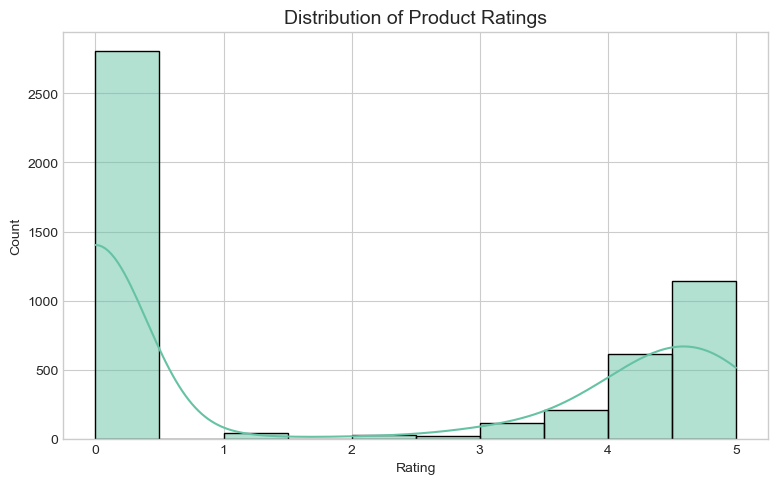

In [17]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
    
# Create a figure with subplots
fig = plt.figure(figsize=(20, 18))
    
# 1. Distribution of product ratings
plt.subplot(3, 2, 1)
sns.histplot(df['Rating'], bins=10, kde=True)
plt.title('Distribution of Product Ratings', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Count')

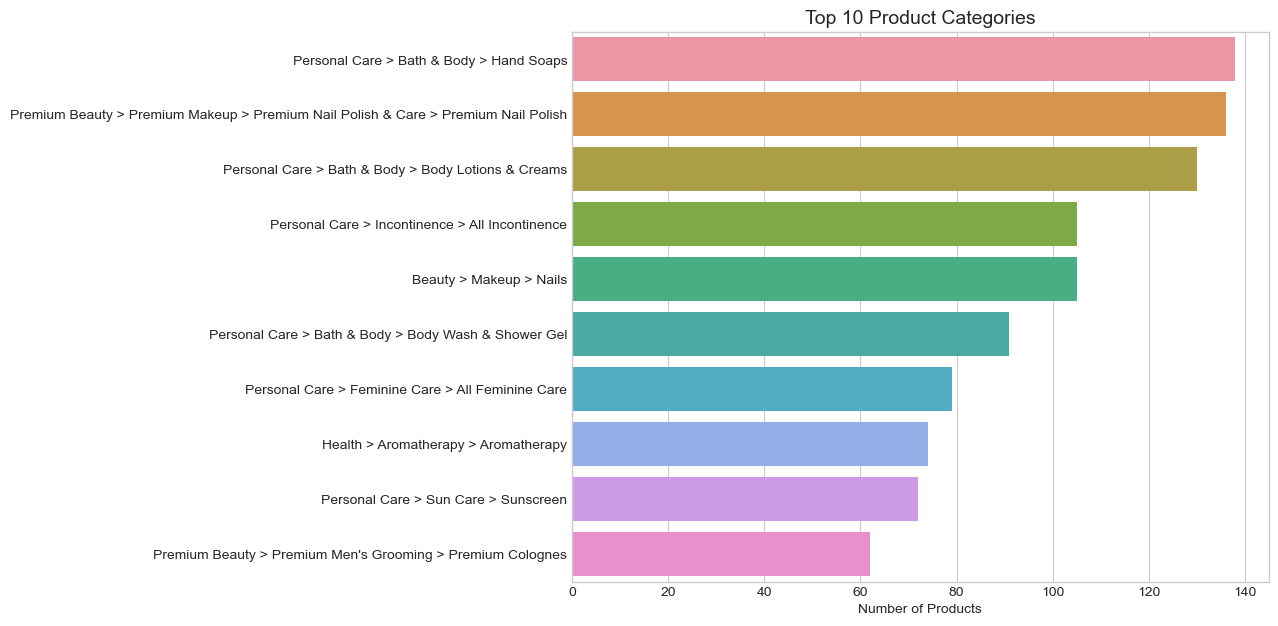

In [22]:
fig = plt.figure(figsize=(20, 18))

# 2. Top categories by number of products
plt.subplot(3, 2, 2)
category_counts = df['Category'].value_counts().head(10)
sns.barplot(x=category_counts.values, y=category_counts.index)
plt.title('Top 10 Product Categories', fontsize=14)
plt.xlabel('Number of Products')
plt.tight_layout()

Text(0.5, 0, 'Average Rating')

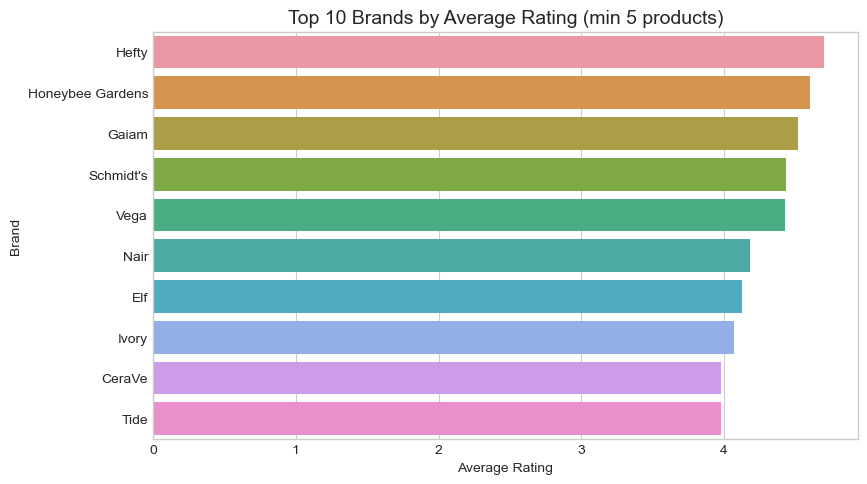

In [25]:
fig = plt.figure(figsize=(20, 18))

plt.subplot(3, 2, 4)
brand_ratings = df.groupby('Brand').agg({
        'Rating': ['mean', 'count']
    })
brand_ratings.columns = ['Avg Rating', 'Count']
top_brands = brand_ratings[brand_ratings['Count'] >= 5].sort_values('Avg Rating', ascending=False).head(10)
sns.barplot(x=top_brands['Avg Rating'], y=top_brands.index)
plt.title('Top 10 Brands by Average Rating (min 5 products)', fontsize=14)
plt.xlabel('Average Rating')

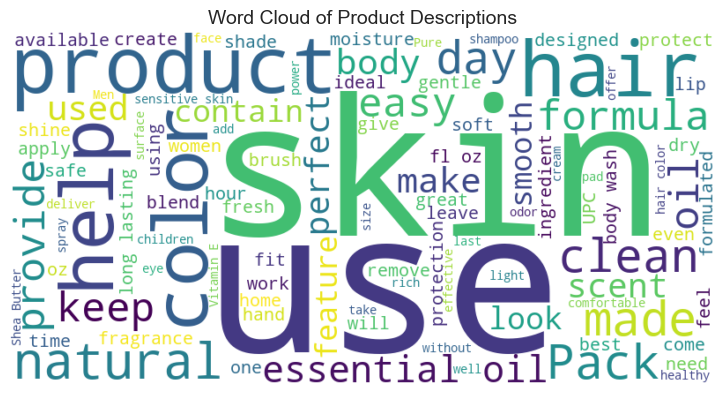

In [26]:
fig = plt.figure(figsize=(20, 18))


try:
    from wordcloud import WordCloud
    plt.subplot(3, 2, 5)
        
    # Combine all descriptions
    all_descriptions = ' '.join(df['Description'].dropna())
        
    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, 
                            background_color='white',
                            max_words=100).generate(all_descriptions)
        
    # Display the word cloud
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Product Descriptions', fontsize=14)
except ImportError:
    plt.subplot(3, 2, 5)
    plt.text(0.5, 0.5, "WordCloud package not available.\nInstall with: pip install wordcloud", 
                ha='center', va='center', fontsize=14)
    plt.axis('off')

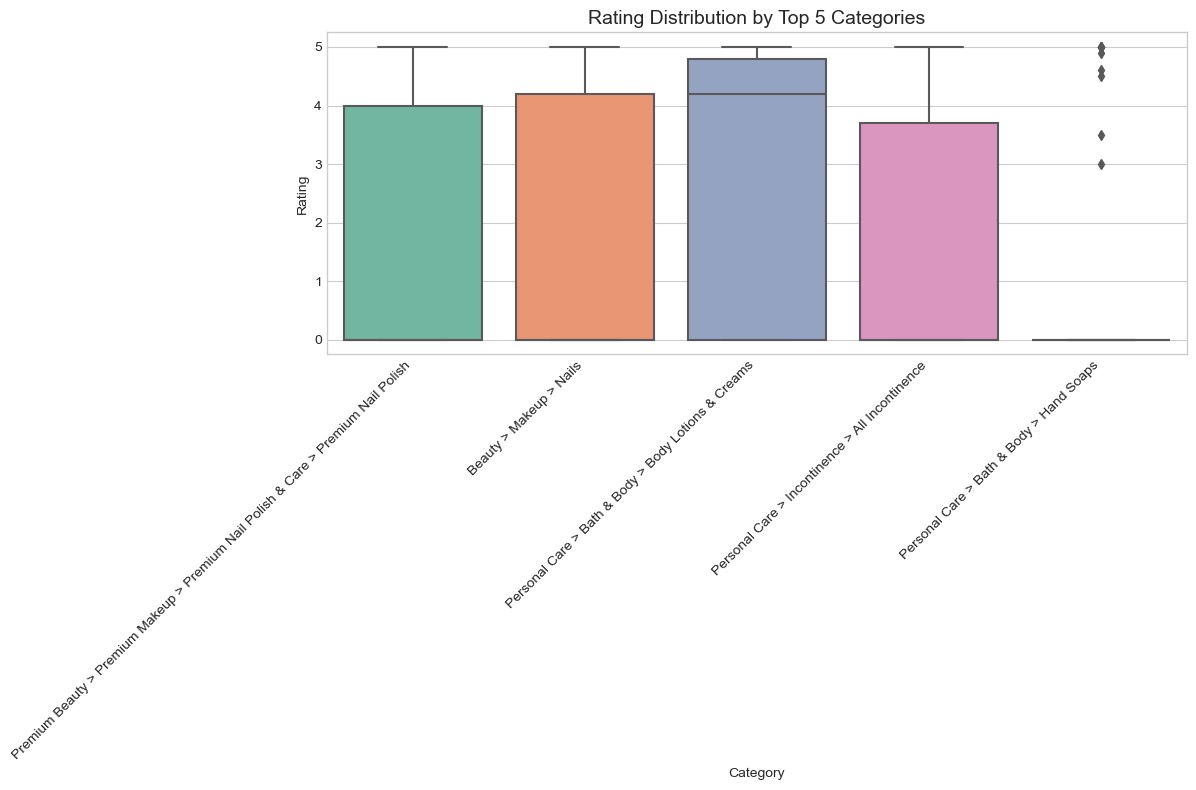

In [ ]:
plt.figure(figsize=(12, 8))

top_5_categories = df['Category'].value_counts().head(5).index
category_df = df[df['Category'].isin(top_5_categories)]
    
sns.boxplot(x='Category', y='Rating', data=category_df)
plt.title('Rating Distribution by Top 5 Categories', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## clean text and create tags

In [33]:
import re
import warnings
import time
from collections import Counter
import spacy

In [ ]:
# Try to import spaCy and load the English model
try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
    SPACY_AVAILABLE = True
    ALL_STOP_WORDS = spacy.lang.en.stop_words.STOP_WORDS
    print("spaCy loaded, advanced NLP available.")
except (ImportError, OSError):
    SPACY_AVAILABLE = False
    # Fallback: simple stop-word list (augment as needed)
    ALL_STOP_WORDS = {
        "the", "and", "is", "in", "to", "of", "for", "on", "with", "a", "an"
    }
    print("spaCy not available, falling back to simple tokenization.")

def clean_text_and_create_tags(df):
    """
    Clean text data and create enhanced tags from product information.

    Parameters:
    df (pd.DataFrame): DataFrame with product data. Must contain columns
                       ['Name', 'Category', 'Brand', 'Description', 'Tags']

    Returns:
    pd.DataFrame: DataFrame with additional columns:
                  - Raw_<col> backups
                  - 'Tags': weighted, filtered tag string
                  - 'Content': combined field for TF-IDF
    """
    print("Cleaning text and generating enhanced tags...")
    start_time = time.time()

    def clean_and_extract_tags(text, min_token_length=3, max_token_length=20):
        if not isinstance(text, str) or not text.strip():
            return []

        # Lowercase & remove non-alphanumeric (except whitespace)
        text = re.sub(r"[^\w\s]", " ", text.lower())

        tags = []
        if SPACY_AVAILABLE:
            doc = nlp(text)
            for token in doc:
                t = token.text
                if (
                    t not in ALL_STOP_WORDS and
                    token.is_alpha and
                    not t.isdigit() and
                    min_token_length <= len(t) <= max_token_length
                ):
                    if token.pos_ in ["NOUN", "PROPN"]:
                        tags.append(t)
                    elif token.pos_ == "ADJ" and token.i + 1 < len(doc) and doc[token.i + 1].pos_ in ["NOUN", "PROPN"]:
                        tags.append(f"{t}_{doc[token.i + 1].text}")

            # Include certain named entities
            for ent in doc.ents:
                if ent.label_ in ["PRODUCT", "ORG", "PERSON", "GPE", "LOC", "WORK_OF_ART"]:
                    clean_ent = re.sub(r"[^\w\s]", " ", ent.text.lower()).strip()
                    if min_token_length <= len(clean_ent) <= max_token_length * 2:
                        tags.append(clean_ent.replace(" ", "_"))
        else:
            for token in text.split():
                if (
                    token not in ALL_STOP_WORDS and
                    token.isalnum() and
                    not token.isdigit() and
                    min_token_length <= len(token) <= max_token_length
                ):
                    tags.append(token)

        return tags

    # Columns to process
    cols = ["Name", "Category", "Brand", "Description", "Tags"]

    # Backup raw columns
    for col in cols:
        df[f"Raw_{col}"] = df[col].astype(str)

    # Extract tags per column
    for col in cols:
        print(f"  → processing '{col}'")
        df[f"{col}_tags"] = df[f"Raw_{col}"].apply(clean_and_extract_tags)

    # Combine tags and dedupe while preserving order
    df["Enhanced_Tags"] = df.apply(
        lambda row: list(dict.fromkeys(
            tag for col in cols for tag in row[f"{col}_tags"]
        )),
        axis=1
    )

    # Count global frequencies
    all_tags = [t for tags in df["Enhanced_Tags"] for t in tags]
    tag_counter = Counter(all_tags)

    # Frequency thresholds
    min_freq = 2
    max_freq = len(df) * 0.5

    # Filter by frequency
    df["Important_Tags"] = df["Enhanced_Tags"].apply(
        lambda tags: [t for t in tags if min_freq <= tag_counter[t] <= max_freq]
    )

    # Turn into weighted string
    def weighted_str(tags):
        return " ".join(sorted(tags, key=lambda t: -tag_counter[t])) if tags else ""

    df["Tags"] = df["Important_Tags"].apply(weighted_str)

    # Build final content field
    df["Content"] = (
        df["Raw_Name"] + " " +
        df["Raw_Brand"] + " " +
        df["Raw_Category"] + " " +
        df["Tags"] + " " +
        df["Raw_Description"]
    )

    # Clean up intermediate columns
    to_drop = [f"{col}_tags" for col in cols] + ["Enhanced_Tags", "Important_Tags"]
    df.drop(columns=to_drop, inplace=True)

    elapsed = time.time() - start_time
    print(f"Done in {elapsed:.2f}s.")
    return df

spaCy loaded, advanced NLP available.


In [37]:
df= clean_text_and_create_tags(df)
df[["Name", "Tags", "Content"]].head()

Cleaning text and generating enhanced tags...
  → processing 'Name'
  → processing 'Category'
  → processing 'Brand'
  → processing 'Description'
  → processing 'Tags'
Done in 174.66s.


,Name,Tags,Content
0,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",beauty premium makeup bath nail polish premium...,"OPI Infinite Shine, Nail Lacquer Nail Polish, ..."
1,"Nice n Easy Permanent Color, 111 Natural Mediu...",beauty pack color formula oil hair ingredients...,"Nice n Easy Permanent Color, 111 Natural Mediu..."
2,Clairol Nice N Easy Permanent Color 7/106A Nat...,beauty color hair home quality conditioner shi...,Clairol Nice N Easy Permanent Color 7/106A Nat...
3,"Kokie Professional Matte Lipstick, Hot Berry, ...",beauty color makeup lip application lipstick m...,"Kokie Professional Matte Lipstick, Hot Berry, ..."
4,"Gillette TRAC II Plus Razor Blade Refills, Fit...",skin personal_care pack use face gel essential...,"Gillette TRAC II Plus Razor Blade Refills, Fit..."


## content recommender model

In [66]:
def build_content_model(product_df):
    """
    Build the content-based filtering model using TF-IDF and cosine similarity
    
    Parameters:
    product_df (pd.DataFrame): Preprocessed product dataframe with 'ProdID', 'Content', etc.
    
    Returns:
    dict: Content model with TF-IDF vectorizer, matrix and similarity matrix
    """
    print("Building content-based model...")
    start_time = time.time()
    
    # Create TF-IDF matrix
    tfidf = TfidfVectorizer(min_df=2, max_df=0.7, 
                           stop_words='english', 
                           ngram_range=(1, 2))
    
    tfidf_matrix = tfidf.fit_transform(product_df['Content'])
    
    # Calculate similarity matrix
    content_similarity = cosine_similarity(tfidf_matrix)
    
    # Create mapping dictionaries for product IDs to matrix indices
    prod_id_to_index = {prod_id: i for i, prod_id in enumerate(product_df['ProdID'])}
    index_to_prod_id = {i: prod_id for prod_id, i in prod_id_to_index.items()}
    
    content_model = {
        'tfidf': tfidf,
        'tfidf_matrix': tfidf_matrix,
        'similarity': content_similarity,
        'prod_id_to_index': prod_id_to_index,
        'index_to_prod_id': index_to_prod_id
    }
    
    elapsed = time.time() - start_time
    print(f"Content model built: {tfidf_matrix.shape[0]} products, {tfidf_matrix.shape[1]} features in {elapsed:.2f}s")
    return content_model

def get_content_recommendations(product_id, content_model, product_df, n=10):
    """
    Get content-based recommendations for a product
    
    Parameters:
    product_id (str): ID of the product to get recommendations for
    content_model (dict): Content-based model from build_content_model()
    product_df (pd.DataFrame): Product dataframe
    n (int): Number of recommendations to return
    
    Returns:
    pd.DataFrame: Recommended products with similarity scores
    """
    # Get the index of the product
    prod_idx = content_model['prod_id_to_index'].get(product_id)
    if prod_idx is None:
        print(f"Product ID {product_id} not found in the dataset")
        return pd.DataFrame()
    
    # Get similarity scores and indices of top n similar products
    sim_scores = list(enumerate(content_model['similarity'][prod_idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]  # Skip the first one (itself)
    product_indices = [i[0] for i in sim_scores]
    
    # Create recommendations dataframe
    recommendations = product_df.iloc[product_indices].copy()
    recommendations['Similarity'] = [i[1] for i in sim_scores]
    
    # Select columns to return
    columns_to_return = ['ProdID', 'Name', 'Category', 'Brand', 'Rating', 'Similarity']
    available_columns = [col for col in columns_to_return if col in recommendations.columns]
    
    return recommendations[available_columns]

def evaluate_content_model(content_model, product_df, n_test_products=50):
    """
    Evaluate content-based recommendations
    
    Parameters:
    content_model (dict): Content-based model
    product_df (pd.DataFrame): Product dataframe
    n_test_products (int): Number of products to use for testing
    
    Returns:
    dict: Evaluation metrics
    """
    print("\nEvaluating content-based model...")
    
    metrics = {'coverage': 0, 'category_diversity': 0, 'brand_diversity': 0, 'avg_similarity': 0}
    
    # Sample products for testing
    test_products = np.random.choice(
        list(content_model['prod_id_to_index'].keys()), 
        min(n_test_products, len(content_model['prod_id_to_index'])), 
        replace=False
    )
    
    all_recommendations = []
    for product_id in test_products:
        recs = get_content_recommendations(product_id, content_model, product_df, n=10)
        if not recs.empty:
            all_recommendations.extend(recs['ProdID'].tolist())
    
    # Calculate coverage (percentage of catalog that can be recommended)
    unique_recs = set(all_recommendations)
    metrics['coverage'] = len(unique_recs) / len(product_df) * 100
    
    # Calculate category diversity
    if 'Category' in product_df.columns:
        recommended_products = product_df[product_df['ProdID'].isin(unique_recs)]
        
        # Category diversity
        rec_categories = recommended_products['Category'].nunique()
        total_categories = product_df['Category'].nunique()
        metrics['category_diversity'] = rec_categories / total_categories * 100
        
        # Brand diversity
        if 'Brand' in product_df.columns:
            rec_brands = recommended_products['Brand'].nunique()
            total_brands = product_df['Brand'].nunique()
            metrics['brand_diversity'] = rec_brands / total_brands * 100
    
    # Calculate average similarity within recommendations
    avg_sim_scores = []
    for product_id in test_products[:20]:  # Limit to 20 for efficiency
        recs = get_content_recommendations(product_id, content_model, product_df, n=10)
        if len(recs) > 1:
            rec_indices = [content_model['prod_id_to_index'][pid] for pid in recs['ProdID'] if pid in content_model['prod_id_to_index']]
            if len(rec_indices) > 1:
                sim_sum = 0
                count = 0
                for i in range(len(rec_indices)):
                    for j in range(i+1, len(rec_indices)):
                        sim_sum += content_model['similarity'][rec_indices[i], rec_indices[j]]
                        count += 1
                if count > 0:
                    avg_sim_scores.append(sim_sum / count)
    
    if avg_sim_scores:
        metrics['avg_similarity'] = np.mean(avg_sim_scores)
    
    print(f"Content model evaluation:")
    print(f"  Coverage: {metrics['coverage']:.2f}%")
    print(f"  Category diversity: {metrics['category_diversity']:.2f}%")
    print(f"  Brand diversity: {metrics['brand_diversity']:.2f}%")
    print(f"  Avg similarity within recommendations: {metrics['avg_similarity']:.4f}")
    
    return metrics

def visualize_recommendations(product_id, recommendations, product_df):
    """
    Visualize recommendations for a product
    
    Parameters:
    product_id (str): ID of the reference product
    recommendations (pd.DataFrame): Recommendations from get_content_recommendations
    product_df (pd.DataFrame): Product dataframe
    """
    # Get reference product info
    ref_product = product_df[product_df['ProdID'] == product_id].iloc[0]
    
    # Create a figure with subplots
    plt.figure(figsize=(12, 8))
    
    # Plot similarity scores
    plt.subplot(211)
    
    # Create bar chart of similarities
    sns.barplot(x=recommendations['Name'], y=recommendations['Similarity'])
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Similarity Scores for Products Similar to: {ref_product["Name"]}')
    plt.xlabel('Product')
    plt.ylabel('Similarity Score')
    plt.tight_layout()
    
    print('\n\n')
    # If there's category information, show category distribution
    if 'Category' in recommendations.columns:
        plt.subplot(212)
        category_counts = recommendations['Category'].value_counts()
        sns.barplot(x=category_counts.index, y=category_counts.values)
        plt.xticks(rotation=45, ha='right')
        plt.title('Category Distribution in Recommendations')
        plt.xlabel('Category')
        plt.ylabel('Count')
        plt.tight_layout()
    
    plt.tight_layout(pad=3.0)
    plt.show()

def recommend_products(product_id, product_df, n=10, evaluate=True, visualize=False):
    """
    Generate content-based product recommendations
    
    Parameters:
    product_id (str): Product ID to base recommendations on
    product_df (pd.DataFrame): Product dataframe with 'ProdID' and 'Content' columns
    n (int): Number of recommendations to return
    evaluate (bool): Whether to evaluate the model
    visualize (bool): Whether to visualize the recommendations
    
    Returns:
    pd.DataFrame: Recommended products with similarity scores
    """
    # Check if product exists
    if product_id not in product_df['ProdID'].values:
        print(f"Product ID {product_id} not found in the dataset")
        return pd.DataFrame()
    
    # Get reference product info
    ref_product = product_df[product_df['ProdID'] == product_id].iloc[0]
    print(f"Finding recommendations for: {ref_product['Name']}")
    
    # Build content model
    content_model = build_content_model(product_df)
    
    # Get recommendations
    recommendations = get_content_recommendations(product_id, content_model, product_df, n)
    
    # Evaluate the model if requested
    if evaluate:
        metrics = evaluate_content_model(content_model, product_df)
    
    # Visualize recommendations if requested
    if visualize:
        visualize_recommendations(product_id, recommendations, product_df)
    
    return recommendations

Finding recommendations for: (6 pack) Great Value Marshmallows, 10 oz
Building content-based model...
Content model built: 5000 products, 93653 features in 2.18s

Evaluating content-based model...
Content model evaluation:
  Coverage: 9.20%
  Category diversity: 20.73%
  Brand diversity: 14.93%
  Avg similarity within recommendations: 0.2796





C:\Users\Mohamed Walid\AppData\Local\Temp\ipykernel_11544\1543954387.py:186: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()
C:\Users\Mohamed Walid\AppData\Local\Temp\ipykernel_11544\1543954387.py:188: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout(pad=3.0)


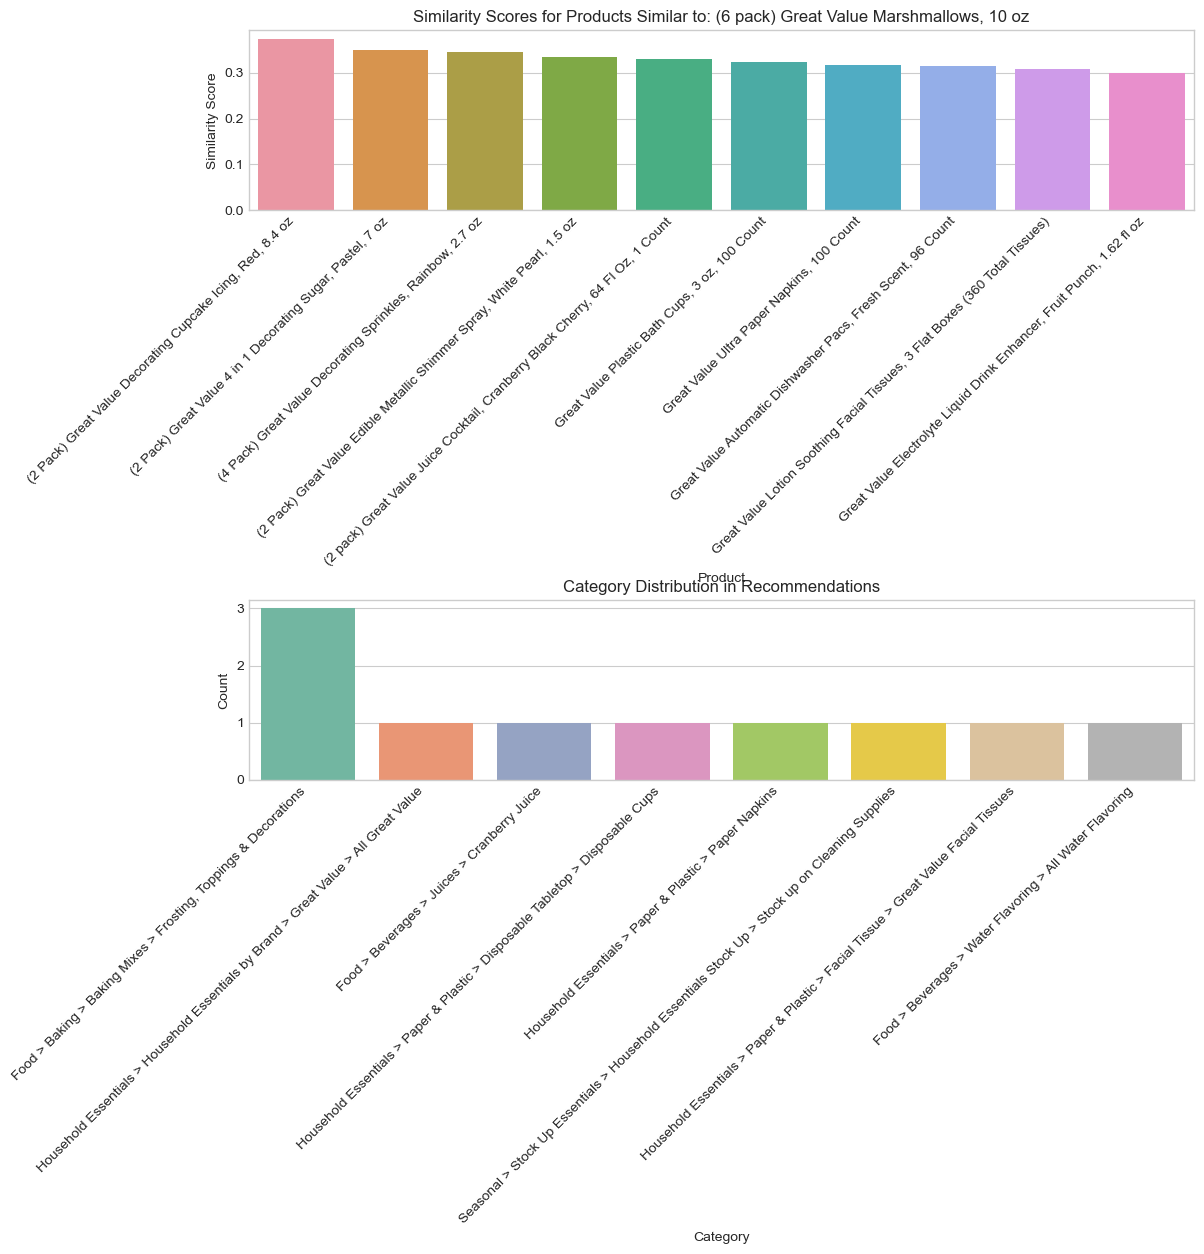


Top recommendations:
                                ProdID  \
4543  3afa1a2eaf44dc0d0247ef7090e2f10a   
3566  ad8a03ee27ac24d6d1eb131389e02973   
2517  f8440df8d6984c28e9146ea9ef38decd   
1986  3ded36ce865b548c0e23296fb2bdecd1   
3289  d71e05c117e8ebca062f07d0d75e5618   
2482  adf2968d0c03b07bc09753dcace138b1   
3356  647a99a063ff89705f839227178569e3   
637   cd0c7ad2974840265393d4fe48c5281b   
681   01b62f74620b01790965fa88a3335d6a   
3162  a1abe79ee054a1647bde31fc2dfc2d36   

                                                   Name  \
4543  (2 Pack) Great Value Decorating Cupcake Icing,...   
3566  (2 Pack) Great Value 4 in 1 Decorating Sugar, ...   
2517  (4 Pack) Great Value Decorating Sprinkles, Rai...   
1986  (2 Pack) Great Value Edible Metallic Shimmer S...   
3289  (2 pack) Great Value Juice Cocktail, Cranberry...   
2482     Great Value Plastic Bath Cups, 3 oz, 100 Count   
3356         Great Value Ultra Paper Napkins, 100 Count   
637   Great Value Automatic Dishwasher Pacs

In [67]:
random_product_id = df['ProdID'].sample(1).iloc[0]

# Get recommendations
recommendations = recommend_products(
    product_id=random_product_id,
    product_df=df,
    n=10,
    evaluate=True,
    visualize=True  # Set to True if you want visualization
)

print("\nTop recommendations:")
print(recommendations)

## Collaborative model